In [1]:
import os
import matplotlib.pyplot as plt
import torch
from torch.amp import autocast
from v1_model import ContinuousMotionModel
from torch.utils.data import DataLoader
from dataset.dataset import *
import utils.utils as utils
from datetime import datetime

In [17]:
# Get the newest model from the directory. That means find the newest folder, and then the newest file in that folder.
model_path = utils.get_latest_model_path("v1_models_sweeped/sliding_vs_normal_models/normal") # or trained_models
print(f"Model path: {model_path}")

# model_path = r"sliding_diffusion_project\v1_models_sweeped\sliding_vs_normal_models\normal\normal_seed_2__3aq6g23e"

# Load the model
model: ContinuousMotionModel = ContinuousMotionModel.load_model(model_path, utils.get_device())
model.condition_mask_probabilty = 0.0  # Disable condition mask probability for inference
model = model.to(utils.get_device())

num_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters in the model: {num_params}")

device = utils.get_device()

Model path: v1_models_sweeped/sliding_vs_normal_models/normal\normal_seed_6__tvr5jvyd\normal_seed_6__tvr5jvyd_epoch_1101.pth
Number of parameters in the model: 9044505


In [45]:
model

ContinuousMotionModel(
  (timestep_mlp): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
  )
  (style_linear): Linear(in_features=17, out_features=64, bias=True)
  (seed_linear): Linear(in_features=0, out_features=192, bias=True)
  (audio_linear): Linear(in_features=37, out_features=64, bias=True)
  (noisy_gesture_linear): Linear(in_features=345, out_features=256, bias=True)
  (pre_local_attention_linear): Linear(in_features=576, out_features=256, bias=True)
  (multi_head_local_attention): LocalMHA(
    (to_qkv): Linear(in_features=256, out_features=768, bias=False)
    (attn_fn): LocalAttention(
      (dropout): Dropout(p=0.0, inplace=False)
      (rel_pos): SinusoidalEmbeddings()
    )
    (to_out): Linear(in_features=256, out_features=256, bias=False)
  )
  (relative_positional_embedding_funtion): SinusoidalEmbeddings()
  (transformer_encoder): TransformerEncoder(
    (layers): Modu

In [7]:
val_loader = DataLoader(
        GPUDataset(
            consolidated_file = "dataset/genea2023_dataset/val/main-agent/consolidated.npz",
            seq_length = 70,
            seed_length = 0,
            batch_size = 64,
            epoch_length = 30,
            loading_encoded_data = False,
            include_vel_acc_features = False,
            device = device,
        ),
        batch_size = 1,
        num_workers = 0,
        pin_memory = False,
    )

Initializing GPU-resident dataset on cuda
Loading data from dataset/genea2023_dataset/val/main-agent/consolidated.npz directly to GPU...
Data loaded to GPU. Gesture shape: torch.Size([75600, 345]), Audio shape: torch.Size([75600, 37])
Found 72771 valid starting points for windows
Dataset initialization complete!


In [47]:
def compute_average_error_matrix(predictions, ground_truths):
    
    assert predictions.shape == ground_truths.shape, "Shape mismatch between predictions and ground truths"
    
    # Compute absolute difference per element
    abs_diff = torch.abs(predictions - ground_truths)  # Shape: (batch_size, *dims)
    
    # Average over the batch dimension
    avg_error_matrix = abs_diff.mean(dim=0)  # Shape: (*dims)
    
    return avg_error_matrix

In [48]:
def visualize_error_matrix(error_matrix, save_dir, filename="average_error.png", cmap="hot"):
    if isinstance(error_matrix, torch.Tensor):
        error_matrix = error_matrix.cpu().numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(error_matrix, cmap=cmap, interpolation='nearest')
    plt.title("Average Per-Pixel Absolute Error")
    plt.colorbar()
    plt.tight_layout()
    plt.close()



In [49]:
def visualize_and_save_error_matrix(error_matrix, save_dir, filename="average_error.png", cmap="hot"):
    if isinstance(error_matrix, torch.Tensor):
        error_matrix = error_matrix.cpu().numpy()

    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, filename)

    plt.figure(figsize=(6, 6))
    plt.imshow(error_matrix, cmap=cmap, interpolation='nearest')
    plt.title("Average Per-Pixel Absolute Error")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

    print(f"Saved error visualization to {save_path}")

In [50]:
all_outputs = []
all_ground_truths = []

with torch.no_grad():
    for val_batch in val_loader:
        gesture_sequence, gesture_seed, audio_features, main_agent_id_one_hot = [
            item.squeeze(0).to(device) for item in val_batch
        ]

        print(f"Processing batch with gesture_sequence shape: {gesture_sequence.shape}, "
              f"gesture_seed shape: {gesture_seed.shape}, "
              f"audio_features shape: {audio_features.shape}, "
              f"main_agent_id_one_hot shape: {main_agent_id_one_hot.shape}")
        
        output, encoded_gesture_sequence, encoded_output, noisy_gesture_sequence = model.generate(
            gesture_sequence            = gesture_sequence,
            audio_features              = audio_features,
            main_agent_id_one_hot       = main_agent_id_one_hot,
            gesture_seed                = gesture_seed,
            gesture_sequence_is_encoded = val_loader.dataset.loading_encoded_data
        )

        print(f"Output shape: {output.shape}")
        # print(output)
        
        all_outputs.append(output.cpu())
        all_ground_truths.append(gesture_sequence.cpu())

Processing batch with gesture_sequence shape: torch.Size([64, 70, 345]), gesture_seed shape: torch.Size([64, 0, 345]), audio_features shape: torch.Size([64, 70, 37]), main_agent_id_one_hot shape: torch.Size([64, 17])
Output shape: torch.Size([64, 70, 345])
Processing batch with gesture_sequence shape: torch.Size([64, 70, 345]), gesture_seed shape: torch.Size([64, 0, 345]), audio_features shape: torch.Size([64, 70, 37]), main_agent_id_one_hot shape: torch.Size([64, 17])
Output shape: torch.Size([64, 70, 345])
Processing batch with gesture_sequence shape: torch.Size([64, 70, 345]), gesture_seed shape: torch.Size([64, 0, 345]), audio_features shape: torch.Size([64, 70, 37]), main_agent_id_one_hot shape: torch.Size([64, 17])
Output shape: torch.Size([64, 70, 345])
Processing batch with gesture_sequence shape: torch.Size([64, 70, 345]), gesture_seed shape: torch.Size([64, 0, 345]), audio_features shape: torch.Size([64, 70, 37]), main_agent_id_one_hot shape: torch.Size([64, 17])
Output shape

In [51]:
all_outputs


[tensor([[[-1.0859e+00, -7.1484e-01, -1.2656e+00,  ...,  5.0781e-01,
           -9.3750e-01,  1.7188e+00],
          [-1.0781e+00, -8.4766e-01, -1.2500e+00,  ...,  4.4531e-01,
           -8.0469e-01,  1.6328e+00],
          [-1.0625e+00, -9.9609e-01, -1.2266e+00,  ...,  3.6133e-01,
           -6.1328e-01,  1.4844e+00],
          ...,
          [-9.8828e-01, -1.3125e+00, -1.5859e+00,  ...,  4.3213e-02,
           -5.7422e-01,  1.6250e+00],
          [-9.3359e-01, -1.2188e+00, -1.7109e+00,  ..., -8.8867e-02,
           -5.1172e-01,  1.6484e+00],
          [-1.0391e+00, -1.1719e+00, -1.7734e+00,  ..., -1.1084e-01,
           -5.3906e-01,  1.5938e+00]],
 
         [[-5.1953e-01, -9.4531e-01,  3.7891e-01,  ..., -2.6172e-01,
            5.7812e-01, -3.4375e-01],
          [-5.5469e-01, -9.6875e-01,  3.6523e-01,  ..., -2.7930e-01,
            5.7422e-01, -2.8320e-01],
          [-5.8594e-01, -9.6094e-01,  3.0859e-01,  ..., -2.8516e-01,
            5.6641e-01, -2.4121e-01],
          ...,
    

In [52]:
all_ground_truths

[tensor([[[-1.0631, -0.7153, -1.2462,  ...,  0.5278, -0.9011,  1.7184],
          [-1.0631, -0.8592, -1.2462,  ...,  0.4595, -0.7653,  1.6205],
          [-1.0631, -1.0034, -1.2262,  ...,  0.3695, -0.5802,  1.4929],
          ...,
          [-1.0198, -1.1477, -1.4884,  ..., -0.0611, -0.4568,  1.5890],
          [-1.0198, -1.1477, -1.5092,  ..., -0.0611, -0.4568,  1.5890],
          [-1.0078, -1.1477, -1.5076,  ..., -0.0592, -0.4568,  1.5872]],
 
         [[-0.4875, -0.9788,  0.4231,  ..., -0.3071,  0.6045, -0.3233],
          [-0.5216, -0.9788,  0.3981,  ..., -0.3210,  0.6045, -0.2837],
          [-0.5553, -0.9788,  0.3525,  ..., -0.3383,  0.6045, -0.2489],
          ...,
          [-0.9253, -1.1230,  0.1592,  ..., -0.2334,  0.4564,  0.2711],
          [-0.9253, -1.1230,  0.1592,  ..., -0.2329,  0.4564,  0.2799],
          [-0.9253, -1.1230,  0.1592,  ..., -0.2324,  0.4564,  0.2785]],
 
         [[-0.3783, -0.0059, -0.0539,  ...,  1.1980, -0.3211, -0.6120],
          [-0.3901, -0.0059,

In [53]:
print(type(all_outputs), len(all_outputs))

# Stack all batches
all_outputs_tensor  = torch.cat(all_outputs, dim=0)                 # Shape: (total_samples, *dims)
all_ground_truths_tensor  = torch.cat(all_ground_truths, dim=0)     # Same shape

# Compute the averaged error matrix
avg_error_matrix = compute_average_error_matrix(all_outputs_tensor, all_ground_truths_tensor)

print(avg_error_matrix.shape)

<class 'list'> 30
torch.Size([70, 345])


In [54]:
all_outputs.clear()
all_ground_truths.clear()

In [55]:
avg_error_matrix

tensor([[0.0265, 0.0241, 0.0220,  ..., 0.0283, 0.0328, 0.0321],
        [0.0257, 0.0233, 0.0208,  ..., 0.0278, 0.0315, 0.0297],
        [0.0244, 0.0225, 0.0206,  ..., 0.0268, 0.0310, 0.0286],
        ...,
        [0.3134, 0.3783, 0.3692,  ..., 0.2789, 0.2319, 0.3023],
        [0.3282, 0.3874, 0.3755,  ..., 0.2927, 0.2455, 0.3188],
        [0.3477, 0.4032, 0.3860,  ..., 0.3054, 0.2556, 0.3317]])

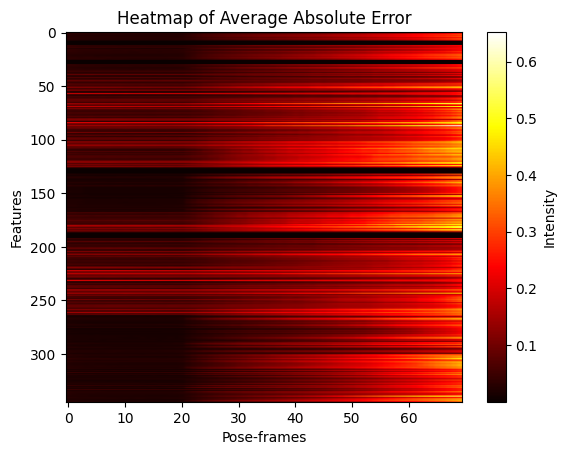

In [56]:
import numpy as np

# Convert tensor to NumPy for plotting
matrix_np = avg_error_matrix.numpy()

matrix_np = np.rot90(matrix_np)

# Plot as heatmap 
plt.imshow(matrix_np, cmap='hot', aspect='auto')
plt.colorbar(label='Intensity')
plt.title('Heatmap of Average Absolute Error')
plt.xlabel('Pose-frames')
plt.ylabel('Features')
plt.show()

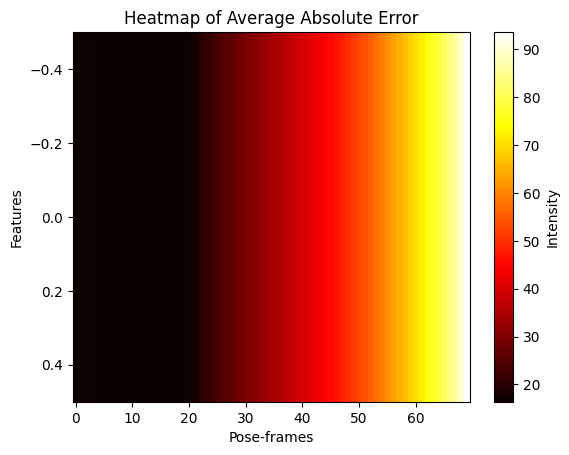

In [ ]:
matrix_np_backup = matrix_np.copy()

x = torch.from_numpy(matrix_np.copy()).float()  # Convert to tensor

collapsed = torch.mean(x, dim=0, keepdim=True)

# Plot
plt.imshow(collapsed, cmap='hot', aspect='auto')
plt.colorbar(label='Intensity')
plt.title('Heatmap of Average Absolute Error - Collapsed rows (Mean)')
plt.xlabel('Pose-frames')
plt.ylabel('Features')
plt.show()

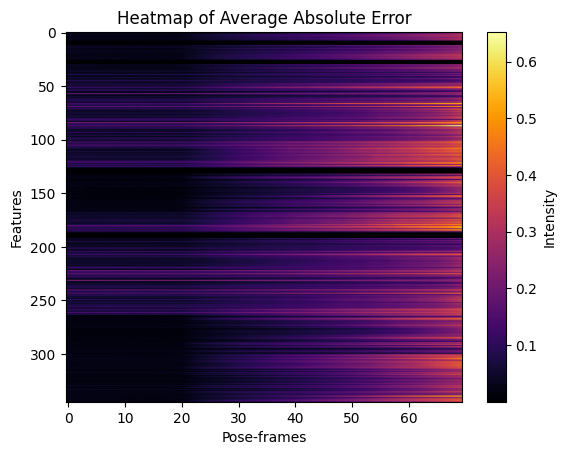

In [58]:
import numpy as np

# Convert tensor to NumPy for plotting
matrix_np = avg_error_matrix.numpy()

matrix_np = np.rot90(matrix_np)

# Plot as heatmap 
plt.imshow(matrix_np, cmap='inferno', aspect='auto')
plt.colorbar(label='Intensity')
plt.title('Heatmap of Average Absolute Error')
plt.xlabel('Pose-frames')
plt.ylabel('Features')
plt.show()

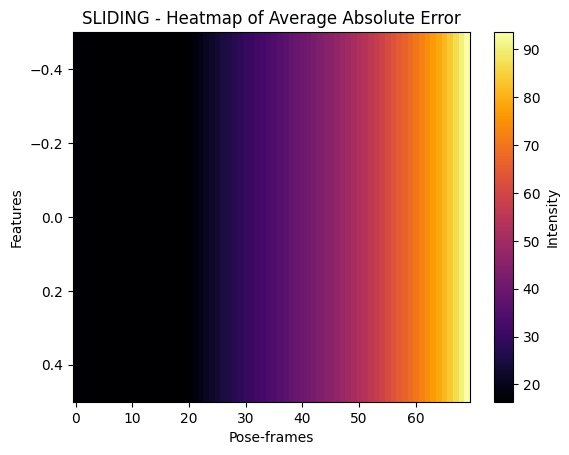

In [59]:
matrix_np_backup = matrix_np.copy()

x = torch.from_numpy(matrix_np.copy()).float()  # Convert to tensor

collapsed = torch.sum(x, dim=0, keepdim=True)

# Plot
plt.imshow(collapsed, cmap='inferno', aspect='auto')
plt.colorbar(label='Intensity')
plt.title('SLIDING - Heatmap of Average Absolute Error')
plt.xlabel('Pose-frames')
plt.ylabel('Features')
plt.show()

In [60]:
# Get the newest model from the directory. That means find the newest folder, and then the newest file in that folder.
model_path = utils.get_latest_model_path("v1_models_sweeped/sliding_vs_normal_models/normal") # or trained_models
print(f"Model path: {model_path}")

# Load the model
model: ContinuousMotionModel = ContinuousMotionModel.load_model(model_path, utils.get_device())
model.condition_mask_probabilty = 0.0  # Disable condition mask probability for inference
model = model.to(utils.get_device())

num_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters in the model: {num_params}")

device = utils.get_device()

Model path: v1_models_sweeped/sliding_vs_normal_models/normal\_normal_diffusion_seed_2__x1ndhnh2\_normal_diffusion_seed_2__x1ndhnh2_epoch_3701.pth
Number of parameters in the model: 8514585


In [61]:
all_outputs = []
all_ground_truths = []

with torch.no_grad():
    for val_batch in val_loader:
        gesture_sequence, gesture_seed, audio_features, main_agent_id_one_hot = [
            item.squeeze(0).to(device) for item in val_batch
        ]

        print(f"Processing batch with gesture_sequence shape: {gesture_sequence.shape}, "
              f"gesture_seed shape: {gesture_seed.shape}, "
              f"audio_features shape: {audio_features.shape}, "
              f"main_agent_id_one_hot shape: {main_agent_id_one_hot.shape}")
        
        output, encoded_gesture_sequence, encoded_output, noisy_gesture_sequence = model.generate(
            gesture_sequence            = gesture_sequence,
            audio_features              = audio_features,
            main_agent_id_one_hot       = main_agent_id_one_hot,
            gesture_seed                = gesture_seed,
            gesture_sequence_is_encoded = val_loader.dataset.loading_encoded_data
        )

        print(f"Output shape: {output.shape}")
        # print(output)
        
        all_outputs.append(output.cpu())
        all_ground_truths.append(gesture_sequence.cpu())

Processing batch with gesture_sequence shape: torch.Size([64, 70, 345]), gesture_seed shape: torch.Size([64, 0, 345]), audio_features shape: torch.Size([64, 70, 37]), main_agent_id_one_hot shape: torch.Size([64, 17])
Output shape: torch.Size([64, 70, 345])
Processing batch with gesture_sequence shape: torch.Size([64, 70, 345]), gesture_seed shape: torch.Size([64, 0, 345]), audio_features shape: torch.Size([64, 70, 37]), main_agent_id_one_hot shape: torch.Size([64, 17])
Output shape: torch.Size([64, 70, 345])
Processing batch with gesture_sequence shape: torch.Size([64, 70, 345]), gesture_seed shape: torch.Size([64, 0, 345]), audio_features shape: torch.Size([64, 70, 37]), main_agent_id_one_hot shape: torch.Size([64, 17])
Output shape: torch.Size([64, 70, 345])
Processing batch with gesture_sequence shape: torch.Size([64, 70, 345]), gesture_seed shape: torch.Size([64, 0, 345]), audio_features shape: torch.Size([64, 70, 37]), main_agent_id_one_hot shape: torch.Size([64, 17])
Output shape

In [62]:
print(type(all_outputs), len(all_outputs))

# Stack all batches
all_outputs_tensor  = torch.cat(all_outputs, dim=0)                 # Shape: (total_samples, *dims)
all_ground_truths_tensor  = torch.cat(all_ground_truths, dim=0)     # Same shape

# Compute the averaged error matrix
avg_error_matrix = compute_average_error_matrix(all_outputs_tensor, all_ground_truths_tensor)

print(avg_error_matrix.shape)

<class 'list'> 30
torch.Size([70, 345])


In [63]:
all_outputs.clear()
all_ground_truths.clear()

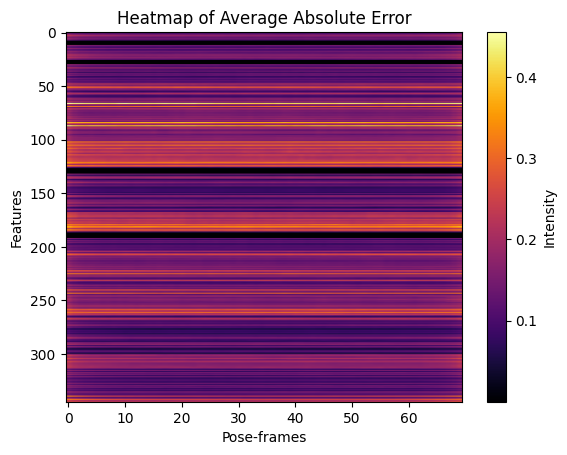

In [64]:
import numpy as np

# Convert tensor to NumPy for plotting
matrix_np = avg_error_matrix.numpy()

matrix_np = np.rot90(matrix_np)

# Plot as heatmap 
plt.imshow(matrix_np, cmap='inferno', aspect='auto')
plt.colorbar(label='Intensity')
plt.title('Heatmap of Average Absolute Error')
plt.xlabel('Pose-frames')
plt.ylabel('Features')
plt.show()

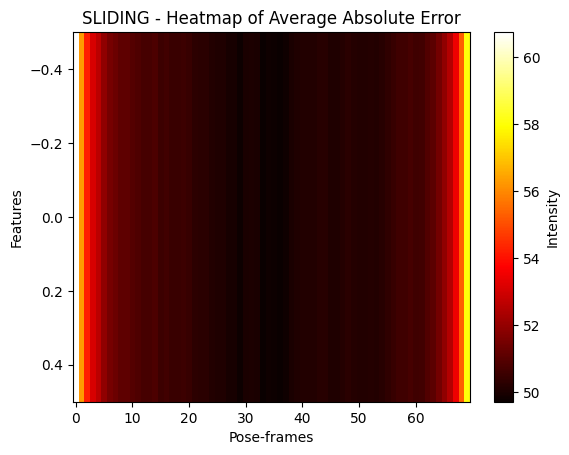

In [65]:
matrix_np_backup = matrix_np.copy()

x = torch.from_numpy(matrix_np.copy()).float()  # Convert to tensor

collapsed = torch.sum(x, dim=0, keepdim=True)

# Plot
plt.imshow(collapsed, cmap='hot', aspect='auto')
plt.colorbar(label='Intensity')
plt.title('SLIDING - Heatmap of Average Absolute Error')
plt.xlabel('Pose-frames')
plt.ylabel('Features')
plt.show()

In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import utils.utils as utils
from typing import Optional, Tuple

def evaluate_and_plot_errors(model_path, val_loader, device, model_type, model_name, save_dir="avg_abs_error_sliding_vs_standard/avg_abs_error_diagram_results", valid_timestep_range: Optional[Tuple[int, int]] = None):
    """
    Loads a model, runs inference on val_loader, computes average error matrix,
    and saves/plots both the full error heatmap and the collapsed (row-averaged) heatmap.

    Args:
        model_path (str): Path to the trained model.
        val_loader (DataLoader): DataLoader for validation data.
        device (torch.device): Device for inference.
        save_dir (str): Directory to save plots.
    """

    # Load model
    model = ContinuousMotionModel.load_model(model_path, utils.get_device())
    model.condition_mask_probabilty = 0.0
    model = model.to(device)

    # Print model info
    num_params = sum(p.numel() for p in model.parameters())
    print(f"Model path: {model_path}")
    print(f"Number of parameters: {num_params}")

    number_of_noisy_tensors_to_print = 1

    # Collect predictions and ground truths
    all_outputs, all_ground_truths = [], []
    with torch.no_grad():
        for val_batch in val_loader:
            gesture_sequence, gesture_seed, audio_features, main_agent_id_one_hot = [
                item.squeeze(0).to(device) for item in val_batch
            ]

            output, *_ = model.generate(
                gesture_sequence=gesture_sequence,
                audio_features=audio_features,
                main_agent_id_one_hot=main_agent_id_one_hot,
                gesture_seed=gesture_seed,
                gesture_sequence_is_encoded=val_loader.dataset.loading_encoded_data,
                valid_timestep_range=valid_timestep_range,
                show_noised_tensor=number_of_noisy_tensors_to_print > 0
            )
            number_of_noisy_tensors_to_print -= 1

            all_outputs.append(output.cpu())
            all_ground_truths.append(gesture_sequence.cpu())

    # Stack batches
    all_outputs_tensor = torch.cat(all_outputs, dim=0)
    all_ground_truths_tensor = torch.cat(all_ground_truths, dim=0)

    # Compute average error matrix
    abs_diff = torch.abs(all_outputs_tensor - all_ground_truths_tensor)
    avg_error_matrix = abs_diff.mean(dim=0)  # (*dims)

    # Convert for plotting
    matrix_np = np.rot90(avg_error_matrix.numpy()).copy()

    os.makedirs(save_dir, exist_ok=True)

    # --- Plot 1: Full heatmap ---
    plt.figure(figsize=(6, 6))
    plt.imshow(matrix_np, cmap='hot', aspect='auto')
    plt.colorbar(label='Intensity')
    plt.title(f'Heatmap of Average Absolute Error - timesteps: {model.diffusion.number_of_timesteps if valid_timestep_range is None else valid_timestep_range}')
    plt.xlabel('Pose-frames')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{model_type}_{model_name}_average_error_heatmap.png"))
    plt.show()

    # --- Plot 2: Collapsed rows ---
    collapsed = torch.mean(torch.from_numpy(matrix_np).float(), dim=0, keepdim=True)
    plt.figure(figsize=(6, 2))
    plt.imshow(collapsed, cmap='hot', aspect='auto')
    plt.colorbar(label='Intensity')
    plt.title(f'Heatmap of Average Absolute Error - Collapsed rows (Mean) - timesteps: {model.diffusion.number_of_timesteps if valid_timestep_range is None else valid_timestep_range}')
    plt.xlabel('Pose-frames')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{model_type}_{model_name}_average_error_collapsed.png"))
    plt.show()

    print(f"Saved plots to {save_dir}")
    print(collapsed)
    return collapsed


In [ ]:
model = ContinuousMotionModel.load_model(r"v1_models_sweeped\sliding_vs_normal_models\normal\normal_seed_2__3aq6g23e\normal_seed_2__3aq6g23e_epoch_1101.pth", utils.get_device())
model.diffusion.number_of_timesteps

100

In [3]:
val_loader = DataLoader(
        GPUDataset(
            consolidated_file = "dataset/genea2023_dataset/val/main-agent/consolidated.npz",
            seq_length = 70,
            seed_length = 8,
            batch_size = 64,
            epoch_length = 30,
            loading_encoded_data = False,
            include_vel_acc_features = False,
            device = utils.get_device(),
        ),
        batch_size = 1,
        num_workers = 0,
        pin_memory = False,
    )

Initializing GPU-resident dataset on cuda
Loading data from dataset/genea2023_dataset/val/main-agent/consolidated.npz directly to GPU...
Data loaded to GPU. Gesture shape: torch.Size([75600, 345]), Audio shape: torch.Size([75600, 37])
Found 72443 valid starting points for windows
Dataset initialization complete!


Model path: v1_models_sweeped\sliding_vs_normal_models\normal\normal_seed_2__3aq6g23e\normal_seed_2__3aq6g23e_epoch_1101.pth
Number of parameters: 9044505


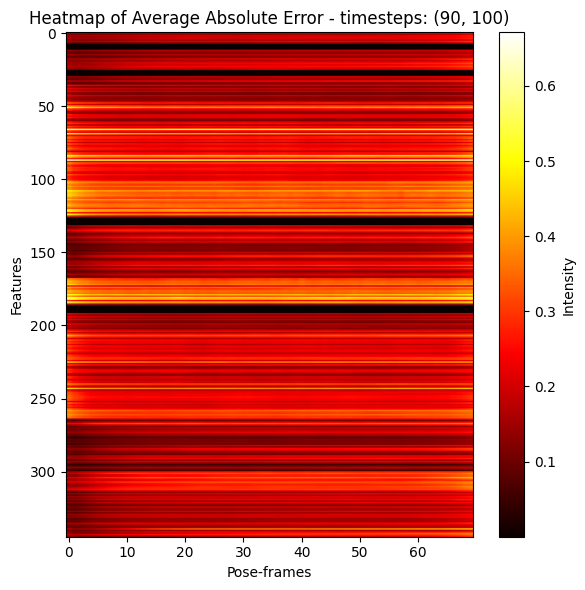

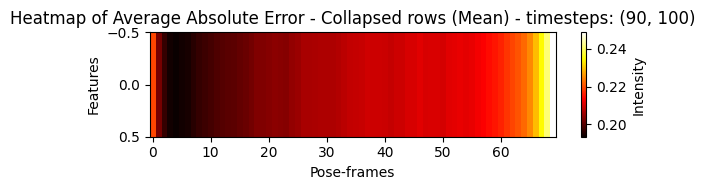

Saved plots to experiement_and_testing_grounds/avg_abs_error_diagram_results
tensor([[0.2194, 0.2024, 0.1970, 0.1940, 0.1933, 0.1940, 0.1944, 0.1958, 0.1968,
         0.1976, 0.1983, 0.1991, 0.1996, 0.1999, 0.2002, 0.2009, 0.2013, 0.2021,
         0.2032, 0.2032, 0.2036, 0.2040, 0.2038, 0.2037, 0.2047, 0.2054, 0.2065,
         0.2064, 0.2066, 0.2068, 0.2069, 0.2069, 0.2073, 0.2081, 0.2086, 0.2088,
         0.2090, 0.2097, 0.2095, 0.2095, 0.2093, 0.2088, 0.2094, 0.2096, 0.2104,
         0.2103, 0.2111, 0.2104, 0.2105, 0.2105, 0.2102, 0.2113, 0.2113, 0.2118,
         0.2115, 0.2118, 0.2127, 0.2134, 0.2145, 0.2154, 0.2165, 0.2178, 0.2191,
         0.2205, 0.2222, 0.2248, 0.2291, 0.2345, 0.2410, 0.2488]])
Model path: v1_models_sweeped\sliding_vs_normal_models\normal\normal_seed_2__3aq6g23e\normal_seed_2__3aq6g23e_epoch_1101.pth
Number of parameters: 9044505


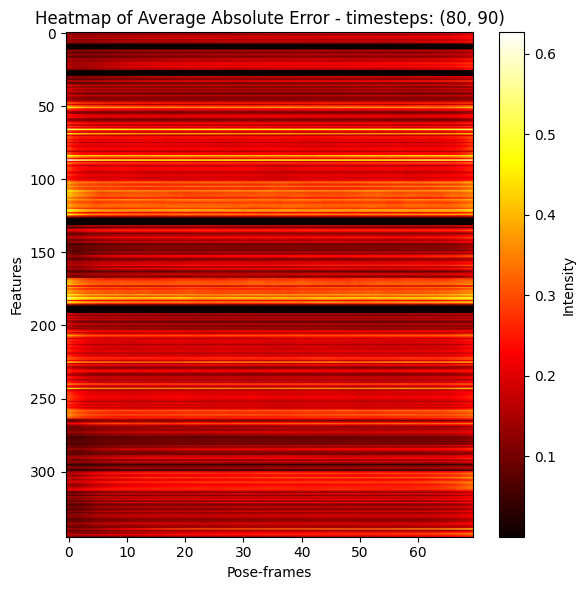

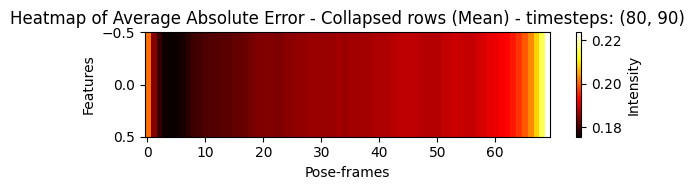

Saved plots to experiement_and_testing_grounds/avg_abs_error_diagram_results
tensor([[0.2012, 0.1845, 0.1789, 0.1760, 0.1756, 0.1761, 0.1767, 0.1780, 0.1793,
         0.1798, 0.1804, 0.1810, 0.1810, 0.1813, 0.1814, 0.1822, 0.1823, 0.1827,
         0.1834, 0.1841, 0.1842, 0.1843, 0.1839, 0.1840, 0.1847, 0.1850, 0.1855,
         0.1854, 0.1859, 0.1859, 0.1858, 0.1859, 0.1860, 0.1866, 0.1860, 0.1866,
         0.1864, 0.1868, 0.1867, 0.1872, 0.1874, 0.1873, 0.1879, 0.1882, 0.1884,
         0.1884, 0.1886, 0.1881, 0.1879, 0.1880, 0.1879, 0.1887, 0.1890, 0.1895,
         0.1892, 0.1890, 0.1891, 0.1900, 0.1906, 0.1917, 0.1919, 0.1930, 0.1935,
         0.1949, 0.1969, 0.1995, 0.2031, 0.2082, 0.2154, 0.2236]])
Model path: v1_models_sweeped\sliding_vs_normal_models\normal\normal_seed_2__3aq6g23e\normal_seed_2__3aq6g23e_epoch_1101.pth
Number of parameters: 9044505


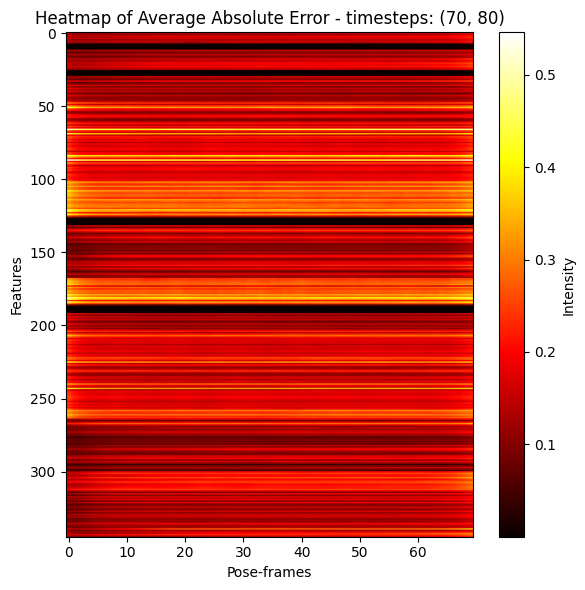

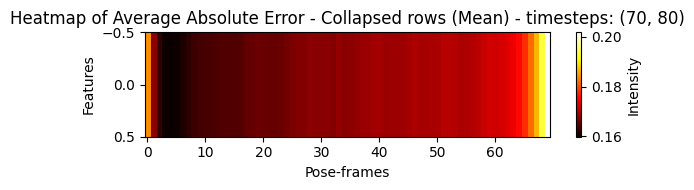

Saved plots to experiement_and_testing_grounds/avg_abs_error_diagram_results
tensor([[0.1841, 0.1682, 0.1623, 0.1602, 0.1598, 0.1601, 0.1611, 0.1620, 0.1629,
         0.1635, 0.1637, 0.1638, 0.1641, 0.1643, 0.1643, 0.1644, 0.1645, 0.1653,
         0.1657, 0.1660, 0.1658, 0.1657, 0.1656, 0.1658, 0.1664, 0.1669, 0.1674,
         0.1674, 0.1679, 0.1678, 0.1678, 0.1677, 0.1675, 0.1685, 0.1678, 0.1680,
         0.1682, 0.1689, 0.1690, 0.1694, 0.1695, 0.1690, 0.1690, 0.1691, 0.1692,
         0.1695, 0.1701, 0.1697, 0.1697, 0.1698, 0.1699, 0.1707, 0.1707, 0.1705,
         0.1699, 0.1701, 0.1705, 0.1710, 0.1717, 0.1725, 0.1723, 0.1727, 0.1733,
         0.1741, 0.1757, 0.1780, 0.1820, 0.1865, 0.1936, 0.2019]])
Model path: v1_models_sweeped\sliding_vs_normal_models\normal\normal_seed_2__3aq6g23e\normal_seed_2__3aq6g23e_epoch_1101.pth
Number of parameters: 9044505


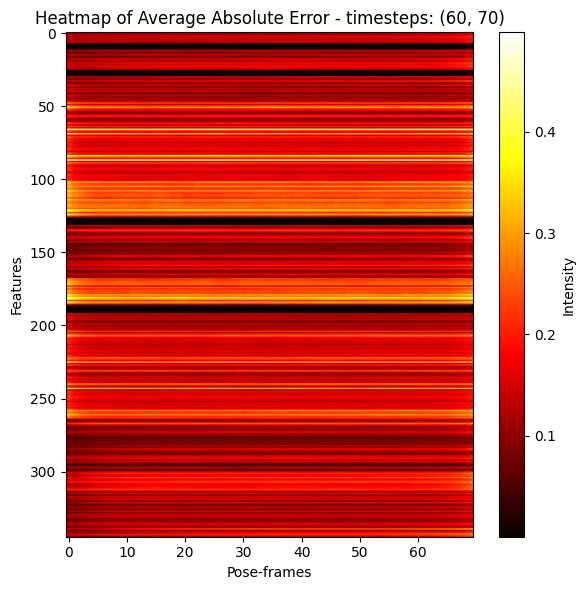

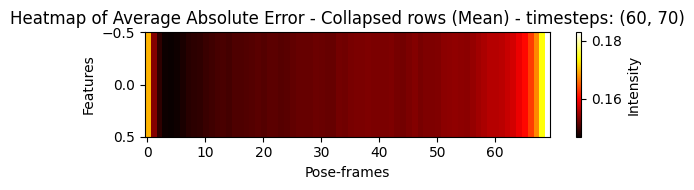

Saved plots to experiement_and_testing_grounds/avg_abs_error_diagram_results
tensor([[0.1698, 0.1537, 0.1490, 0.1471, 0.1470, 0.1473, 0.1479, 0.1486, 0.1489,
         0.1490, 0.1495, 0.1499, 0.1503, 0.1504, 0.1501, 0.1507, 0.1507, 0.1509,
         0.1510, 0.1512, 0.1509, 0.1515, 0.1514, 0.1511, 0.1513, 0.1517, 0.1519,
         0.1519, 0.1520, 0.1522, 0.1520, 0.1519, 0.1520, 0.1526, 0.1525, 0.1530,
         0.1531, 0.1531, 0.1531, 0.1531, 0.1531, 0.1531, 0.1531, 0.1528, 0.1527,
         0.1530, 0.1535, 0.1529, 0.1532, 0.1533, 0.1534, 0.1540, 0.1541, 0.1542,
         0.1540, 0.1539, 0.1545, 0.1550, 0.1556, 0.1562, 0.1561, 0.1565, 0.1572,
         0.1577, 0.1590, 0.1604, 0.1633, 0.1674, 0.1741, 0.1828]])
Model path: v1_models_sweeped\sliding_vs_normal_models\normal\normal_seed_2__3aq6g23e\normal_seed_2__3aq6g23e_epoch_1101.pth
Number of parameters: 9044505


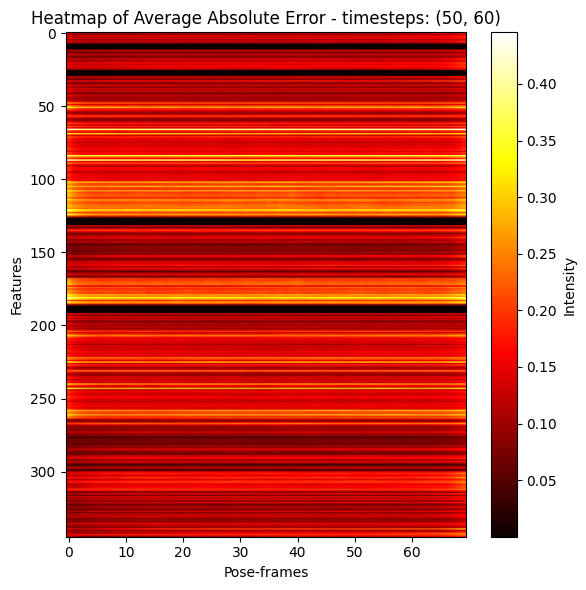

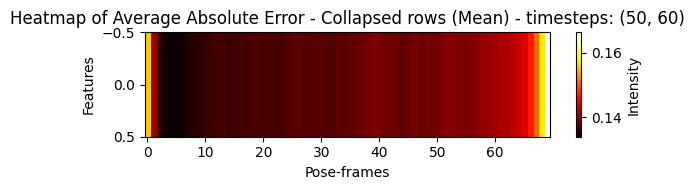

Saved plots to experiement_and_testing_grounds/avg_abs_error_diagram_results
tensor([[0.1555, 0.1408, 0.1363, 0.1346, 0.1341, 0.1342, 0.1344, 0.1352, 0.1354,
         0.1358, 0.1361, 0.1367, 0.1369, 0.1370, 0.1364, 0.1368, 0.1370, 0.1369,
         0.1373, 0.1373, 0.1371, 0.1372, 0.1372, 0.1370, 0.1376, 0.1378, 0.1380,
         0.1377, 0.1377, 0.1378, 0.1377, 0.1376, 0.1374, 0.1381, 0.1381, 0.1383,
         0.1383, 0.1388, 0.1391, 0.1397, 0.1394, 0.1390, 0.1390, 0.1388, 0.1382,
         0.1387, 0.1393, 0.1388, 0.1392, 0.1389, 0.1390, 0.1399, 0.1401, 0.1398,
         0.1396, 0.1395, 0.1398, 0.1401, 0.1408, 0.1410, 0.1414, 0.1418, 0.1417,
         0.1425, 0.1435, 0.1445, 0.1471, 0.1507, 0.1573, 0.1663]])
Model path: v1_models_sweeped\sliding_vs_normal_models\normal\normal_seed_2__3aq6g23e\normal_seed_2__3aq6g23e_epoch_1101.pth
Number of parameters: 9044505


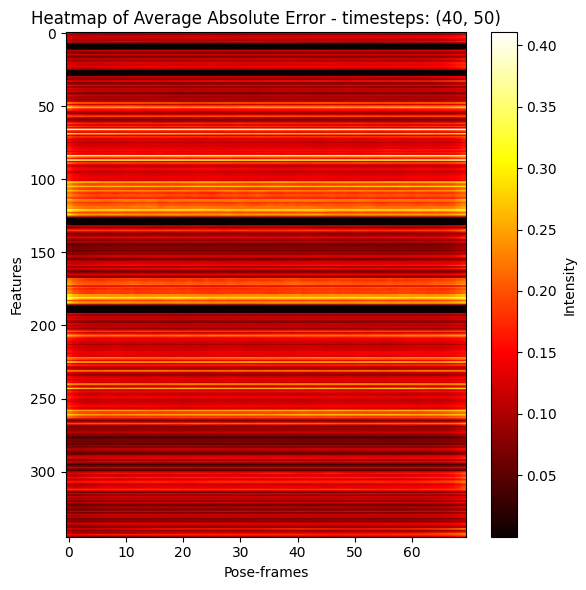

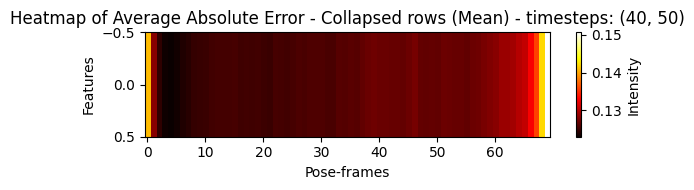

Saved plots to experiement_and_testing_grounds/avg_abs_error_diagram_results
tensor([[0.1409, 0.1282, 0.1245, 0.1232, 0.1229, 0.1233, 0.1238, 0.1242, 0.1247,
         0.1248, 0.1250, 0.1253, 0.1254, 0.1254, 0.1254, 0.1255, 0.1252, 0.1252,
         0.1252, 0.1252, 0.1250, 0.1250, 0.1254, 0.1254, 0.1252, 0.1255, 0.1257,
         0.1255, 0.1258, 0.1258, 0.1258, 0.1256, 0.1256, 0.1261, 0.1260, 0.1262,
         0.1262, 0.1265, 0.1269, 0.1271, 0.1269, 0.1268, 0.1268, 0.1267, 0.1267,
         0.1270, 0.1274, 0.1267, 0.1266, 0.1266, 0.1266, 0.1270, 0.1269, 0.1268,
         0.1268, 0.1266, 0.1270, 0.1271, 0.1276, 0.1279, 0.1282, 0.1289, 0.1289,
         0.1293, 0.1300, 0.1306, 0.1329, 0.1358, 0.1421, 0.1507]])
Model path: v1_models_sweeped\sliding_vs_normal_models\normal\normal_seed_2__3aq6g23e\normal_seed_2__3aq6g23e_epoch_1101.pth
Number of parameters: 9044505


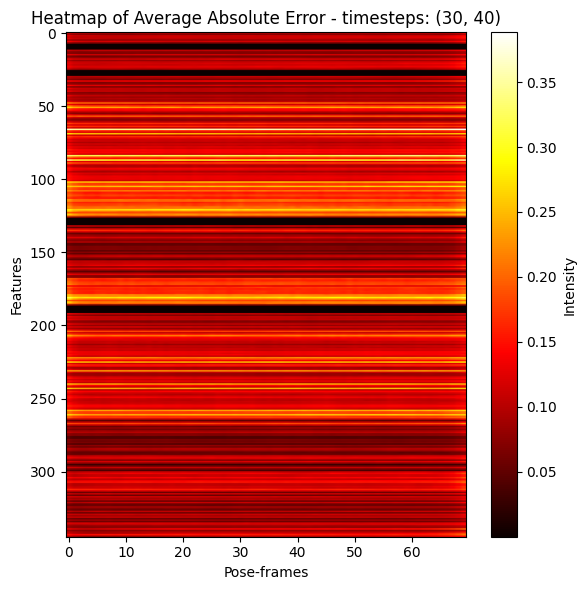

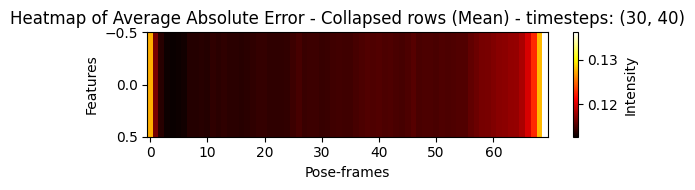

Saved plots to experiement_and_testing_grounds/avg_abs_error_diagram_results
tensor([[0.1274, 0.1166, 0.1138, 0.1129, 0.1127, 0.1129, 0.1130, 0.1137, 0.1136,
         0.1137, 0.1137, 0.1140, 0.1138, 0.1141, 0.1138, 0.1138, 0.1137, 0.1139,
         0.1140, 0.1142, 0.1142, 0.1140, 0.1140, 0.1141, 0.1141, 0.1144, 0.1148,
         0.1144, 0.1145, 0.1145, 0.1142, 0.1144, 0.1145, 0.1146, 0.1145, 0.1146,
         0.1149, 0.1150, 0.1152, 0.1151, 0.1152, 0.1150, 0.1151, 0.1150, 0.1149,
         0.1150, 0.1154, 0.1149, 0.1150, 0.1151, 0.1149, 0.1151, 0.1151, 0.1151,
         0.1152, 0.1152, 0.1158, 0.1161, 0.1165, 0.1166, 0.1169, 0.1171, 0.1173,
         0.1176, 0.1176, 0.1184, 0.1199, 0.1227, 0.1278, 0.1362]])
Model path: v1_models_sweeped\sliding_vs_normal_models\normal\normal_seed_2__3aq6g23e\normal_seed_2__3aq6g23e_epoch_1101.pth
Number of parameters: 9044505


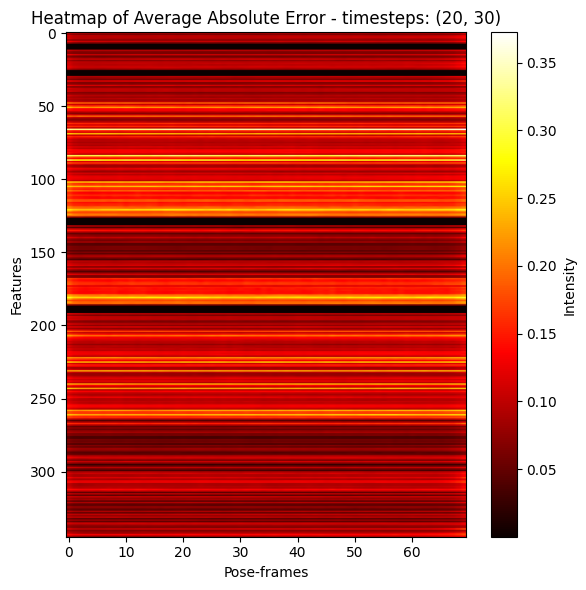

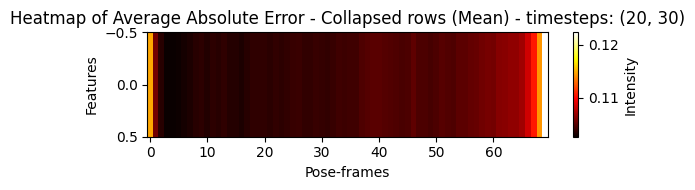

Saved plots to experiement_and_testing_grounds/avg_abs_error_diagram_results
tensor([[0.1148, 0.1058, 0.1035, 0.1026, 0.1026, 0.1027, 0.1030, 0.1032, 0.1035,
         0.1036, 0.1034, 0.1036, 0.1035, 0.1037, 0.1034, 0.1035, 0.1032, 0.1035,
         0.1038, 0.1037, 0.1038, 0.1035, 0.1038, 0.1037, 0.1038, 0.1040, 0.1041,
         0.1038, 0.1038, 0.1040, 0.1039, 0.1038, 0.1040, 0.1042, 0.1041, 0.1042,
         0.1042, 0.1047, 0.1048, 0.1050, 0.1050, 0.1048, 0.1048, 0.1047, 0.1045,
         0.1046, 0.1052, 0.1046, 0.1045, 0.1045, 0.1045, 0.1049, 0.1048, 0.1047,
         0.1050, 0.1050, 0.1052, 0.1053, 0.1056, 0.1058, 0.1057, 0.1063, 0.1064,
         0.1066, 0.1066, 0.1071, 0.1085, 0.1105, 0.1143, 0.1224]])
Model path: v1_models_sweeped\sliding_vs_normal_models\normal\normal_seed_2__3aq6g23e\normal_seed_2__3aq6g23e_epoch_1101.pth
Number of parameters: 9044505


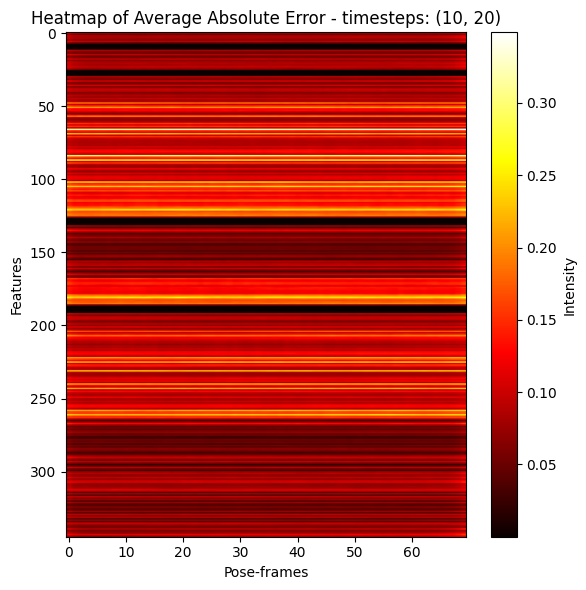

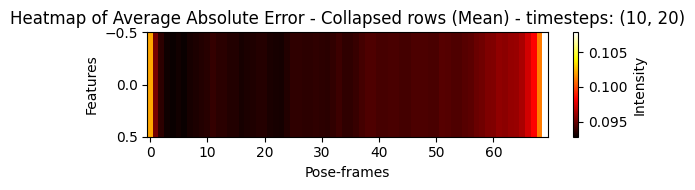

Saved plots to experiement_and_testing_grounds/avg_abs_error_diagram_results
tensor([[0.1021, 0.0953, 0.0936, 0.0930, 0.0928, 0.0930, 0.0929, 0.0932, 0.0933,
         0.0934, 0.0935, 0.0938, 0.0936, 0.0936, 0.0934, 0.0934, 0.0932, 0.0933,
         0.0933, 0.0934, 0.0934, 0.0932, 0.0932, 0.0931, 0.0934, 0.0937, 0.0937,
         0.0936, 0.0936, 0.0937, 0.0936, 0.0935, 0.0937, 0.0940, 0.0937, 0.0937,
         0.0939, 0.0941, 0.0944, 0.0944, 0.0942, 0.0942, 0.0943, 0.0943, 0.0942,
         0.0941, 0.0943, 0.0943, 0.0943, 0.0943, 0.0943, 0.0946, 0.0945, 0.0944,
         0.0944, 0.0946, 0.0947, 0.0950, 0.0952, 0.0954, 0.0955, 0.0959, 0.0957,
         0.0960, 0.0960, 0.0965, 0.0973, 0.0983, 0.1012, 0.1079]])
Model path: v1_models_sweeped\sliding_vs_normal_models\normal\normal_seed_2__3aq6g23e\normal_seed_2__3aq6g23e_epoch_1101.pth
Number of parameters: 9044505


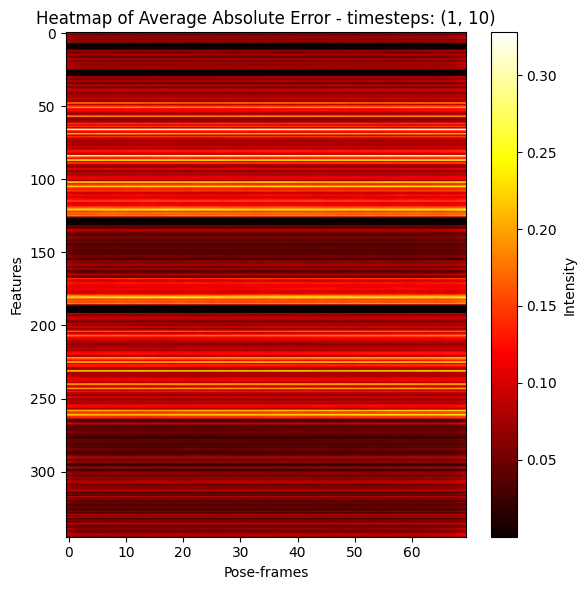

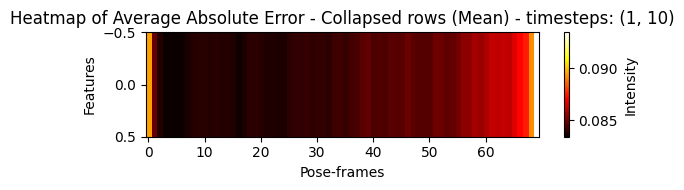

Saved plots to experiement_and_testing_grounds/avg_abs_error_diagram_results
tensor([[0.0895, 0.0848, 0.0838, 0.0835, 0.0834, 0.0835, 0.0835, 0.0837, 0.0838,
         0.0839, 0.0839, 0.0838, 0.0839, 0.0838, 0.0838, 0.0838, 0.0835, 0.0837,
         0.0839, 0.0839, 0.0838, 0.0837, 0.0837, 0.0837, 0.0837, 0.0839, 0.0840,
         0.0840, 0.0841, 0.0840, 0.0840, 0.0840, 0.0840, 0.0842, 0.0842, 0.0841,
         0.0843, 0.0844, 0.0846, 0.0847, 0.0844, 0.0845, 0.0844, 0.0846, 0.0846,
         0.0846, 0.0849, 0.0846, 0.0846, 0.0845, 0.0845, 0.0849, 0.0849, 0.0847,
         0.0848, 0.0850, 0.0854, 0.0854, 0.0858, 0.0856, 0.0858, 0.0862, 0.0861,
         0.0862, 0.0862, 0.0866, 0.0871, 0.0875, 0.0892, 0.0934]])


In [9]:
# intervals
intervals = [
    (90, 100),
    (80, 90),
    (70, 80),
    (60, 70),
    (50, 60),
    (40, 50),
    (30, 40),
    (20, 30),
    (10, 20),
    (1, 10)
]

error_tensors = []

for start, end in intervals:
    error_tensors.append(evaluate_and_plot_errors(model_path=r"v1_models_sweeped\sliding_vs_normal_models\normal\normal_seed_2__3aq6g23e\normal_seed_2__3aq6g23e_epoch_1101.pth", 
                            val_loader=val_loader, 
                            device=utils.get_device(), 
                            model_name="seed_2",
                            model_type="normal",
                            valid_timestep_range=(start, end))
    )

d:\Users\test\miniconda3\envs\sd2\Lib\site-packages\torch\nn\init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Model path: v1_models_sweeped\sliding_vs_normal_models\sliding\_sliding_diffusion_seed_3__ricv3wye\_sliding_diffusion_seed_3__ricv3wye_epoch_4701.pth
Number of parameters: 8514585


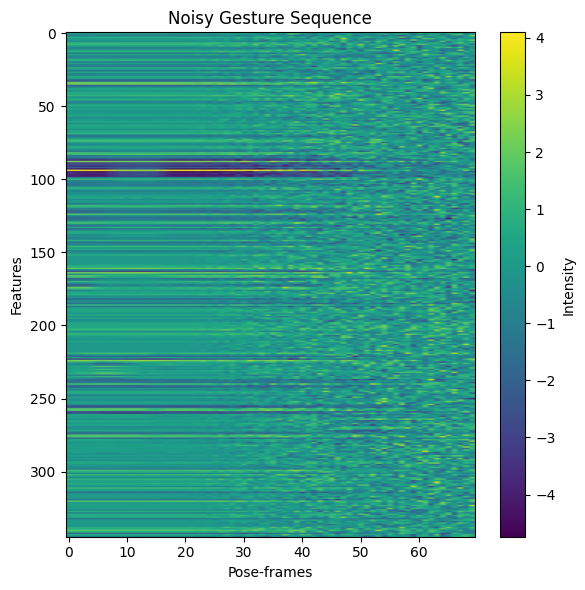

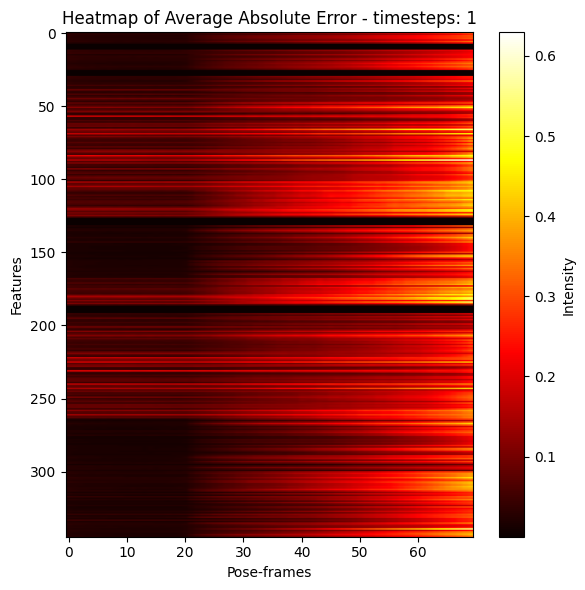

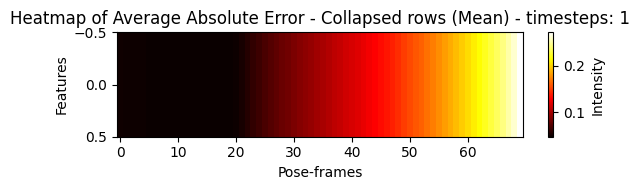

Saved plots to experiement_and_testing_grounds/avg_abs_error_diagram_results
tensor([[0.0496, 0.0488, 0.0484, 0.0483, 0.0482, 0.0481, 0.0480, 0.0478, 0.0479,
         0.0478, 0.0478, 0.0477, 0.0475, 0.0475, 0.0474, 0.0473, 0.0472, 0.0473,
         0.0475, 0.0476, 0.0483, 0.0522, 0.0567, 0.0608, 0.0646, 0.0685, 0.0721,
         0.0756, 0.0790, 0.0823, 0.0856, 0.0889, 0.0919, 0.0947, 0.0976, 0.1008,
         0.1040, 0.1073, 0.1102, 0.1135, 0.1164, 0.1191, 0.1227, 0.1263, 0.1297,
         0.1335, 0.1369, 0.1406, 0.1445, 0.1495, 0.1538, 0.1583, 0.1624, 0.1670,
         0.1716, 0.1770, 0.1823, 0.1874, 0.1932, 0.1985, 0.2038, 0.2095, 0.2154,
         0.2220, 0.2290, 0.2362, 0.2441, 0.2526, 0.2620, 0.2727]])


In [4]:
sliding_error_tensor = evaluate_and_plot_errors(model_path=r"v1_models_sweeped\sliding_vs_normal_models\sliding\_sliding_diffusion_seed_3__ricv3wye\_sliding_diffusion_seed_3__ricv3wye_epoch_4701.pth", 
                         val_loader=val_loader, 
                         device=utils.get_device(), 
                         model_name="seed_2",
                         model_type="sliding",)

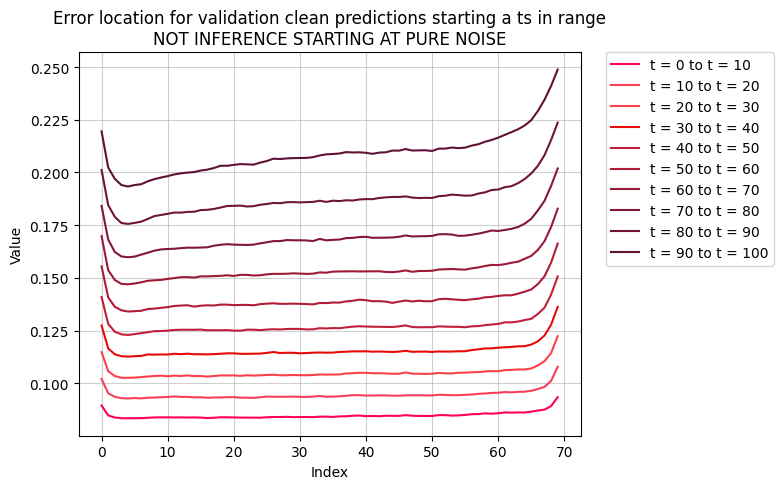

In [29]:
def plot_tensors(tensor_list, sliding_error_tensor):
    """
    Plots a list of PyTorch tensors as separate lines on a single graph
    with high-contrast colors for a white background.
    
    Args:
        tensor_list (list of torch.Tensor): List of tensors where each tensor
                                            has the same number of elements.
    """
    # Strong, high-contrast colors (no white, yellow, or light tones)
    colors = [
        "#ff005c",
        "#f73e5d",
        "#fa414a",
        "#e60b09",
        "#bf1f39",
        "#b01c37", 
        "#9c1937", 
        "#821736",
        "#701537", 
        "#5e1236", 
    ]
    
    plt.figure(figsize=(8, 5))

    for idx, t in enumerate(tensor_list[::-1]):
        values = t.flatten().numpy()
        plt.plot(
            range(len(values)), 
            values, 
            label=f"t = {(idx) * 10} to t = {(idx+1) * 10}", 
            color=colors[idx % len(colors)], 
            marker=''
        )
    
    # values = sliding_error_tensor.flatten().numpy()
    # plt.plot(
    #     range(len(values)), 
    #     values, 
    #     label=f"sliding - with all its ts", 
    #     color="#6ad991", 
    #     marker=''
    # )
    
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.title("Error location for validation clean predictions starting a ts in range\nNOT INFERENCE STARTING AT PURE NOISE")
    plt.legend()
    plt.grid(True, linestyle='-', alpha=0.6)

    # Move legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()


# Example usage:
tensors = error_tensors

plot_tensors(tensors, sliding_error_tensor)

In [ ]:
model = ContinuousMotionModel.load_model(r"v1_models_sweeped\sliding_vs_normal_models\normal\normal_seed_2__3aq6g23e\normal_seed_2__3aq6g23e_epoch_1101.pth", utils.get_device())

per_sequence_timestep = torch.randint(0, model.diffusion.number_of_timesteps, (encoded_gesture_sequence.shape[0],), device=model.device)

noisy_gesture_sequence = model.diffusion.forward(encoded_gesture_sequence, per_sequence_timestep)

plt.figure(figsize=(6, 6))
plt.imshow(noisy_gesture_sequence, cmap='Greens', aspect='auto')
plt.colorbar(label='Intensity')
plt.title(f'Heatmap of Average Absolute Error - timesteps: {model.diffusion.number_of_timesteps if valid_timestep_range is None else valid_timestep_range}')
plt.xlabel('Pose-frames')
plt.ylabel('Features')
plt.tight_layout()

NameError: name 'encoded_gesture_sequence' is not defined

In [15]:
error_tensors

[tensor([[0.2194, 0.2024, 0.1970, 0.1940, 0.1933, 0.1940, 0.1944, 0.1958, 0.1968,
          0.1976, 0.1983, 0.1991, 0.1996, 0.1999, 0.2002, 0.2009, 0.2013, 0.2021,
          0.2032, 0.2032, 0.2036, 0.2040, 0.2038, 0.2037, 0.2047, 0.2054, 0.2065,
          0.2064, 0.2066, 0.2068, 0.2069, 0.2069, 0.2073, 0.2081, 0.2086, 0.2088,
          0.2090, 0.2097, 0.2095, 0.2095, 0.2093, 0.2088, 0.2094, 0.2096, 0.2104,
          0.2103, 0.2111, 0.2104, 0.2105, 0.2105, 0.2102, 0.2113, 0.2113, 0.2118,
          0.2115, 0.2118, 0.2127, 0.2134, 0.2145, 0.2154, 0.2165, 0.2178, 0.2191,
          0.2205, 0.2222, 0.2248, 0.2291, 0.2345, 0.2410, 0.2488]]),
 tensor([[0.2012, 0.1845, 0.1789, 0.1760, 0.1756, 0.1761, 0.1767, 0.1780, 0.1793,
          0.1798, 0.1804, 0.1810, 0.1810, 0.1813, 0.1814, 0.1822, 0.1823, 0.1827,
          0.1834, 0.1841, 0.1842, 0.1843, 0.1839, 0.1840, 0.1847, 0.1850, 0.1855,
          0.1854, 0.1859, 0.1859, 0.1858, 0.1859, 0.1860, 0.1866, 0.1860, 0.1866,
          0.1864, 0.1868, 0.1

d:\Users\test\miniconda3\envs\sd2\Lib\site-packages\torch\nn\init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Model path: v1_models_sweeped\sliding_vs_normal_models\sliding\_sliding_diffusion_seed_3__ricv3wye\_sliding_diffusion_seed_3__ricv3wye_epoch_4701.pth
Number of parameters: 8514585


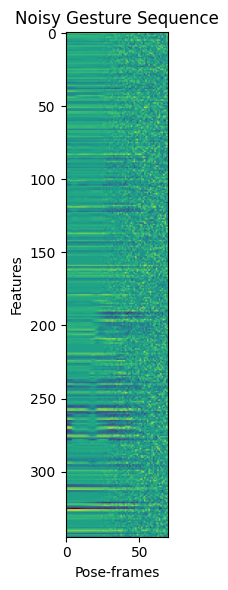

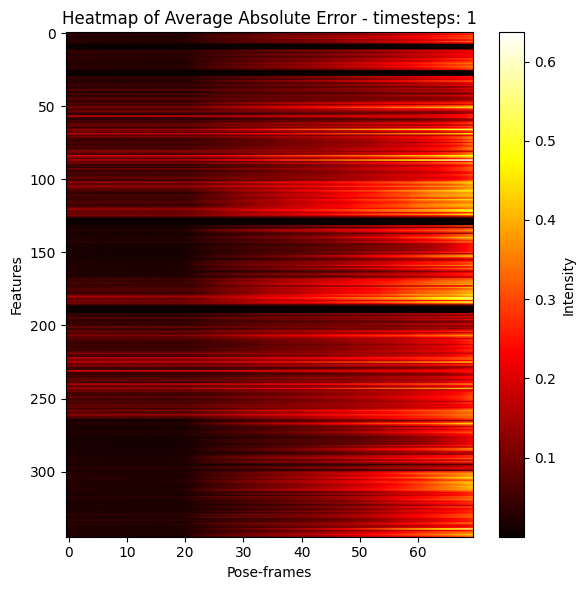

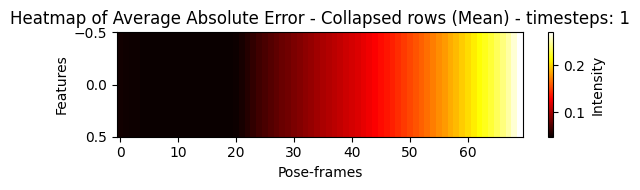

Saved plots to experiement_and_testing_grounds/avg_abs_error_diagram_results
tensor([[0.0503, 0.0495, 0.0489, 0.0485, 0.0484, 0.0482, 0.0481, 0.0479, 0.0477,
         0.0478, 0.0477, 0.0478, 0.0477, 0.0476, 0.0476, 0.0476, 0.0476, 0.0477,
         0.0478, 0.0480, 0.0486, 0.0527, 0.0570, 0.0612, 0.0652, 0.0689, 0.0723,
         0.0759, 0.0791, 0.0823, 0.0854, 0.0885, 0.0915, 0.0946, 0.0978, 0.1011,
         0.1041, 0.1068, 0.1093, 0.1121, 0.1151, 0.1180, 0.1212, 0.1246, 0.1285,
         0.1323, 0.1360, 0.1395, 0.1439, 0.1481, 0.1525, 0.1569, 0.1609, 0.1658,
         0.1710, 0.1760, 0.1807, 0.1864, 0.1912, 0.1967, 0.2025, 0.2085, 0.2140,
         0.2199, 0.2262, 0.2334, 0.2415, 0.2503, 0.2602, 0.2706]])


tensor([[0.0503, 0.0495, 0.0489, 0.0485, 0.0484, 0.0482, 0.0481, 0.0479, 0.0477,
         0.0478, 0.0477, 0.0478, 0.0477, 0.0476, 0.0476, 0.0476, 0.0476, 0.0477,
         0.0478, 0.0480, 0.0486, 0.0527, 0.0570, 0.0612, 0.0652, 0.0689, 0.0723,
         0.0759, 0.0791, 0.0823, 0.0854, 0.0885, 0.0915, 0.0946, 0.0978, 0.1011,
         0.1041, 0.1068, 0.1093, 0.1121, 0.1151, 0.1180, 0.1212, 0.1246, 0.1285,
         0.1323, 0.1360, 0.1395, 0.1439, 0.1481, 0.1525, 0.1569, 0.1609, 0.1658,
         0.1710, 0.1760, 0.1807, 0.1864, 0.1912, 0.1967, 0.2025, 0.2085, 0.2140,
         0.2199, 0.2262, 0.2334, 0.2415, 0.2503, 0.2602, 0.2706]])

In [4]:
evaluate_and_plot_errors(model_path=r"v1_models_sweeped\sliding_vs_normal_models\sliding\_sliding_diffusion_seed_3__ricv3wye\_sliding_diffusion_seed_3__ricv3wye_epoch_4701.pth", 
                         val_loader=val_loader, 
                         device=utils.get_device(), 
                         model_name="seed_2",
                         model_type="sliding",)